# Regression Model Comparison

## Overview
This notebook focuses on the comparative evaluation of multiple machine learning regression algorithms for predicting compound bioactivity using molecular descriptor data.

The workflow includes:
- Dataset preparation
- Model training across multiple regression algorithms
- Performance evaluation and benchmarking
- Comparative analysis of predictive accuracy

## Objectives
The objective is to identify and compare regression models capable of accurately predicting pIC50 values for acetylcholinesterase inhibitors.

## Models Evaluated
- Linear Regression
- Random Forest Regressor
- Support Vector Regressor (SVR)
- Decision Tree Regressor

## Tools and Libraries
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

## Acknowledgment
Initial workflow inspired by educational content from Data Professor.

## Import Required Libraries

In [ ]:
! pip install lazypredict

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

## Load Modeling Dataset

In [ ]:
! wget https://github.com/dataprofessor/data/raw/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv

--2026-05-10 20:16:25--  https://github.com/dataprofessor/data/raw/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv [following]
--2026-05-10 20:16:25--  https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8363909 (8.0M) [text/plain]
Saving to: ‘acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_

In [ ]:
df = pd.read_csv('bioactivity.csv')

In [ ]:
X = df.drop('pIC50', axis=1)
Y = df.pIC50

## Data Preprocessing

In [ ]:
# Examine X dimension
X.shape

(4695, 881)

In [ ]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)
X.shape

(4695, 137)

In [ ]:
# Perform data splitting using 80/20 ratio
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## Regression Model Comparison

In [ ]:
clf = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
train, train_predictions = clf.fit(X_train, X_train, Y_train, Y_train)

In [ ]:
train

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreeRegressor,0.859408,0.864538,0.571388,0.156617
DecisionTreeRegressor,0.859408,0.864538,0.571388,0.111510
ExtraTreesRegressor,0.859408,0.864538,0.571388,5.164980
GaussianProcessRegressor,0.859408,0.864538,0.571388,4.708963
RandomForestRegressor,0.822878,0.829340,0.641338,3.541399
XGBRegressor,0.819598,0.826180,0.647249,0.282371
BaggingRegressor,0.804288,0.811428,0.674155,0.413167
MLPRegressor,0.757521,0.766367,0.750392,3.707037
HistGradientBoostingRegressor,0.674207,0.686094,0.869805,0.789774


In [ ]:
clf = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
test, test_predictions = clf.fit(X_train, X_test, Y_train, Y_test)

In [ ]:
test

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
HistGradientBoostingRegressor,0.455519,0.535044,1.059035,0.798754
RandomForestRegressor,0.438623,0.520616,1.075341,3.478338
LGBMRegressor,0.437692,0.519820,1.076233,0.226658
XGBRegressor,0.436528,0.518826,1.077346,0.280250
BaggingRegressor,0.405035,0.491933,1.107044,0.464140
NuSVR,0.389303,0.478499,1.121584,0.940913
SVR,0.389268,0.478469,1.121616,1.186039
KNeighborsRegressor,0.371334,0.463154,1.137965,0.122309
MLPRegressor,0.358628,0.452304,1.149408,3.695984


## Model Performance Visualization

[(0.0, 1.0)]

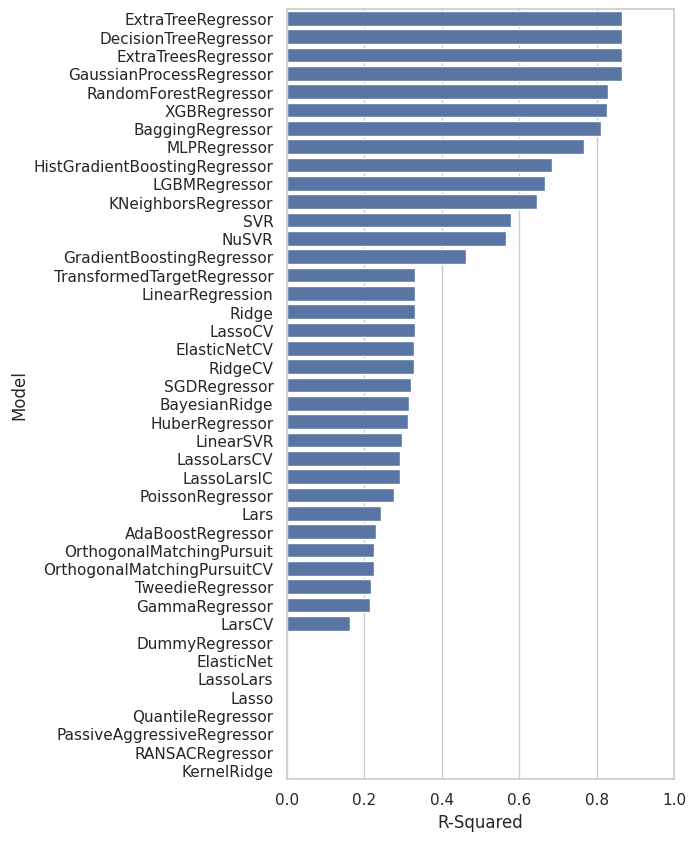

In [ ]:
# Bar plot of R-squared values
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=train.index, x="R-Squared", data=train)
ax.set(xlim=(0, 1))

[(0.0, 10.0)]

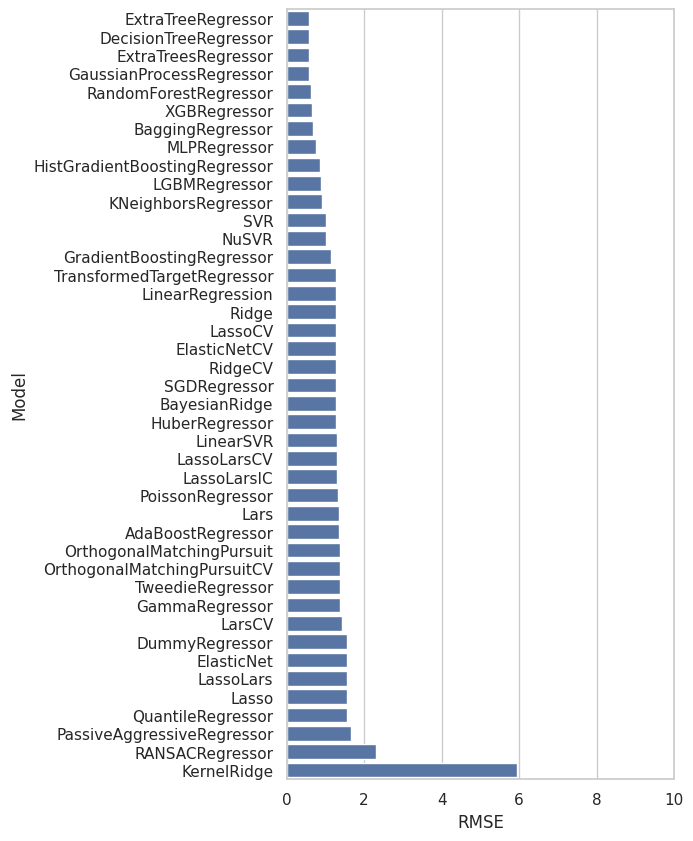

In [ ]:
# Bar plot of RMSE values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=train.index, x="RMSE", data=train)
ax.set(xlim=(0, 10))

[(0.0, 10.0)]

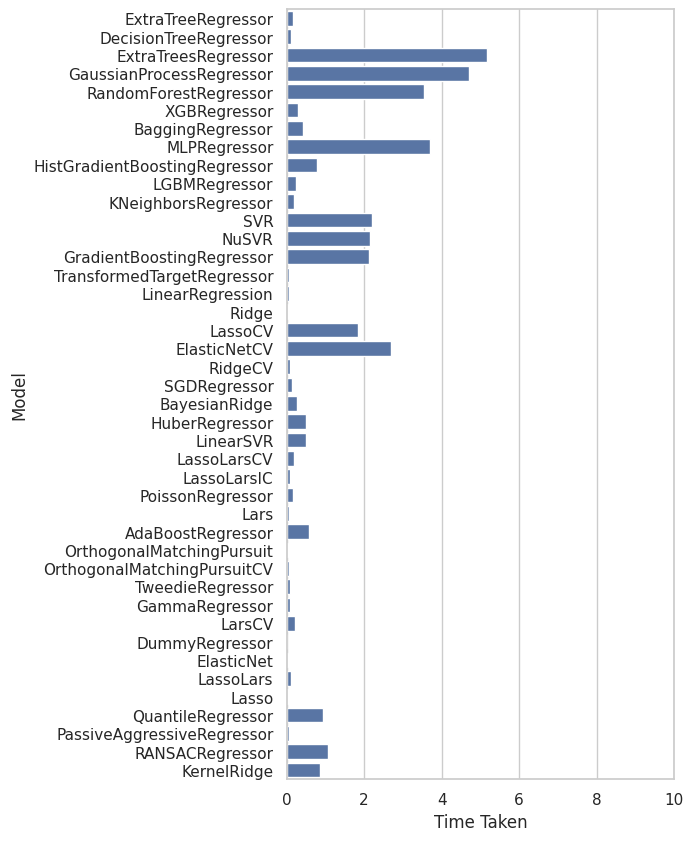

In [ ]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=train.index, x="Time Taken", data=train)
ax.set(xlim=(0, 10))